# ResNet18 Fine-tuned — NWPU-RESISC45
**Model 2 of 3** | ImageNet weights · Transfer Learning · Freeze backbone → Unfreeze

## Imports

In [1]:
import time
import os
from typing import Dict, List

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchinfo import summary
from torchvision import datasets, transforms
import torchvision.models as models

## Device Check

In [2]:
print(torch.cuda.is_available())
print(torch.cuda.current_device())
print(torch.cuda.get_device_name(0))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
MODEL_PATH = "resnet18_finetuned_best.pth"


True
0
NVIDIA T1200 Laptop GPU
Using device: cuda


## Dataset Preparation

### 1. Transforms
Same ImageNet normalization stats — since we start from ImageNet pretrained weights, this is essential.

In [ ]:

def get_resisc45_transforms(img_size=224, augment=True):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    train_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),           # extra augmentation for satellite imagery
        transforms.RandomRotation(degrees=15),     # rotation invariance for aerial views
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ]) if augment else transforms.Compose([
        transforms.Resize(int(img_size * 1.14)),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    val_tf = transforms.Compose([
        transforms.Resize(int(img_size * 1.14)),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    return train_tf, val_tf

### 2. DataLoader Setup

In [ ]:
# Custom Dataset wrapper to apply transforms to subsets created by random_split
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label

    def __len__(self):
        return len(self.subset)

In [ ]:
# Data loading function with 70/15/15 split and transformations
def get_dataloaders(data_root, img_size=224, batch_size=32):

    train_tf, val_tf = get_resisc45_transforms(img_size)

    base_dataset = datasets.ImageFolder(root=data_root)

    n_total = len(base_dataset)
    n_train = int(0.7 * n_total)
    n_val   = int(0.15 * n_total)
    n_test  = n_total - n_train - n_val

    train_ds, val_ds, test_ds = random_split(
        base_dataset,
        [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(42) 
    )

    train_ds = TransformSubset(train_ds, train_tf)
    val_ds   = TransformSubset(val_ds, val_tf)
    test_ds  = TransformSubset(test_ds, val_tf)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=0, pin_memory=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=0, pin_memory=True
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=0, pin_memory=True
    )

    return train_loader, val_loader, test_loader

## Architecture ResNet18 Fine-tuned

We load the official torchvision ResNet18 with ImageNet pretrained weights, then replace the final classifier head for 45 classes.

Training strategy:
1. **Phase 1: Freeze backbone**: Only classifier head is trained. High LR, fast convergence.
2. **Phase 2: Unfreeze**: Entire network fine-tuned end-to-end with a much lower LR.

In [ ]:
def build_resnet18_finetuned(num_classes: int = 45, dropout_p: float = 0.3) -> nn.Module:
    # Load pretrained backbone
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Replace classifier head
    in_features = model.fc.in_features 
    model.fc = nn.Sequential(
        nn.Dropout(p=dropout_p),
        nn.Linear(in_features, num_classes)
    )

    return model

# Freeze all layers except the final classifier head
def freeze_backbone(model: nn.Module):
    for name, param in model.named_parameters():
        if not name.startswith("fc"):
            param.requires_grad = False

    frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[Freeze] Frozen: {frozen:,} | Trainable: {trainable:,}")

# Unfreeze layers from a specified point to allow fine-tuning of deeper layers
def unfreeze_backbone(model: nn.Module, unfreeze_from_layer: str = "layer3"):
   
    layers_order = ["layer1", "layer2", "layer3", "layer4", "fc"]
    start_idx = layers_order.index(unfreeze_from_layer)
    layers_to_unfreeze = set(layers_order[start_idx:])

    for name, param in model.named_parameters():
        top_layer = name.split(".")[0]
        if top_layer in layers_to_unfreeze:
            param.requires_grad = True

    frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[Unfreeze from '{unfreeze_from_layer}'] Frozen: {frozen:,} | Trainable: {trainable:,}")

## Training Functions

In [ ]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
):

    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(
            device,
            non_blocking=True,
            dtype=torch.float32
        )

        labels = labels.to(
            device,
            non_blocking=True
        )
        optimizer.zero_grad(set_to_none=True)

        # FORWARD PASS
        logits = model(images)
        loss = criterion(logits, labels)

        if torch.isnan(loss):
            print(" NaN loss detected, skipping batch")
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )
        optimizer.step()
        
        # METRICS
        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += images.size(0)
        
    # RETURN FINAL METRIC
    return {
        "loss": total_loss / total,
        "acc": correct / total
    }

### Evaluate

In [8]:
@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        logits = model(images)
        loss   = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

    return {"loss": total_loss / total, "acc": correct / total}

### Two-Phase Training Loop

**Phase 1**: Frozen backbone train classifier head only with high LR.

**Phase 2**: Unfreeze from "layer3" onwards fine-tune end-to-end with low LR.

In [ ]:
def train_two_phase(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    # Phase 1 settings
    phase1_epochs: int = 10,
    phase1_lr: float = 1e-3,
    # Phase 2 settings
    phase2_epochs: int = 40,
    phase2_lr: float = 1e-4,
    unfreeze_from: str = "layer3",
    # General
    weight_decay: float = 1e-4,
    save_path: str = "resnet18_finetuned_best.pth",
    device_str: str = "auto",
):
    device = (
        torch.device("cuda" if torch.cuda.is_available() else "cpu")
        if device_str == "auto"
        else torch.device(device_str)
    )
    print(f"Training on: {device}")

    model = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    best_val_acc = 0.0
    patience = 10
    patience_ctr = 0
    history = []

    # PHASE 1: Frozen backbone (head only)
    print("  PHASE 1: Frozen backbone — training classifier head")
    freeze_backbone(model)

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=phase1_lr,
        weight_decay=weight_decay
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=phase1_epochs)

    for epoch in range(1, phase1_epochs + 1):
        t0 = time.time()
        train_stats = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_stats   = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        lr_now = optimizer.param_groups[0]['lr']
        elapsed = time.time() - t0

        print(
            f"[P1 Ep {epoch:02d}/{phase1_epochs}] "
            f"Train Loss: {train_stats['loss']:.4f} | Train Acc: {train_stats['acc']:.4f} | "
            f"Val Loss: {val_stats['loss']:.4f} | Val Acc: {val_stats['acc']:.4f} | "
            f"LR: {lr_now:.2e} | {elapsed:.1f}s"
        )

        history.append({"phase": 1, "epoch": epoch, **train_stats, **{f"val_{k}": v for k, v in val_stats.items()}})

        if val_stats['acc'] > best_val_acc:
            best_val_acc = val_stats['acc']
            torch.save({"model_state": model.state_dict(), "val_acc": best_val_acc, "phase": 1}, save_path)
            print(f" New best saved: {best_val_acc:.4f}")

    # PHASE 2: Unfreeze
    print(f"  PHASE 2: Unfreeze from '{unfreeze_from}' — end-to-end fine-tune")
    unfreeze_backbone(model, unfreeze_from_layer=unfreeze_from)

    # Use differential learning rates: lower LR for backbone, higher for head
    backbone_params = [p for n, p in model.named_parameters() if not n.startswith("fc") and p.requires_grad]
    head_params     = [p for n, p in model.named_parameters() if n.startswith("fc") and p.requires_grad]

    optimizer = torch.optim.Adam([
        {"params": backbone_params, "lr": phase2_lr * 0.1},   # backbone: 10x lower
        {"params": head_params,     "lr": phase2_lr},          # head: normal
    ], weight_decay=weight_decay)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=phase2_epochs)
    patience_ctr = 0

    for epoch in range(1, phase2_epochs + 1):
        t0 = time.time()
        train_stats = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_stats   = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        lr_now = optimizer.param_groups[0]['lr']
        elapsed = time.time() - t0

        print(
            f"[P2 Ep {epoch:02d}/{phase2_epochs}] "
            f"Train Loss: {train_stats['loss']:.4f} | Train Acc: {train_stats['acc']:.4f} | "
            f"Val Loss: {val_stats['loss']:.4f} | Val Acc: {val_stats['acc']:.4f} | "
            f"LR: {lr_now:.2e} | {elapsed:.1f}s"
        )

        history.append({"phase": 2, "epoch": epoch, **train_stats, **{f"val_{k}": v for k, v in val_stats.items()}})

        if val_stats['acc'] > best_val_acc:
            best_val_acc = val_stats['acc']
            patience_ctr = 0
            torch.save({"model_state": model.state_dict(), "val_acc": best_val_acc, "phase": 2}, save_path)
            print(f" New best saved: {best_val_acc:.4f}")
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"\n Early stopping at epoch {epoch} (no improvement for {patience} epochs)")
                break

    print(f"\nTraining complete. Best val acc: {best_val_acc:.4f}")
    return history

## Visualization Before Training

Shows class distribution and a preview batch (after transforms) before training starts.

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter


def visualize_before_training(data_root: str, train_loader: DataLoader, preview_count: int = 8):
    base_dataset = datasets.ImageFolder(root=data_root)
    class_names = base_dataset.classes
    class_counts = Counter(base_dataset.targets)

    # Preview transformed training samples
    images, labels = next(iter(train_loader))
    images = images[:preview_count].cpu().numpy().transpose(0, 2, 3, 1)

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    images = np.clip(images * std + mean, 0, 1)

    cols = min(4, preview_count)
    rows = int(np.ceil(preview_count / cols))
    plt.figure(figsize=(4 * cols, 3 * rows))
    for i in range(preview_count):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
    plt.suptitle("Pre-Training Sample Preview (With Augmentations)", y=1.02)
    plt.tight_layout()
    plt.show()

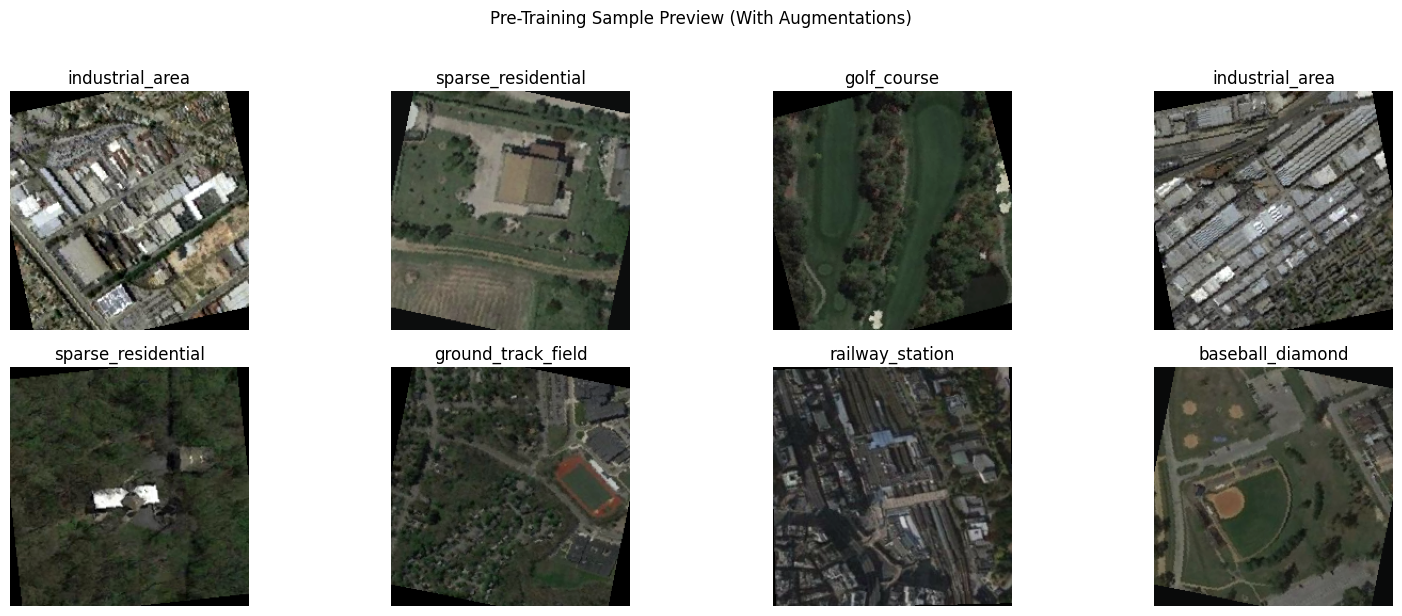

In [ ]:

# VISUALIZATION BEFORE TRAINING
data_path  = r"D:\DELL\Documents\deeplearning_proj\NWPU-RESISC45" 
train_loader, val_loader, test_loader = get_dataloaders(data_path, img_size=224, batch_size=32)
visualize_before_training(data_path, train_loader, preview_count=8)

## Run

In [ ]:

# CONFIG
data_path  = r"D:\DELL\Documents\deeplearning_proj\NWPU-RESISC45"   # same as Model 1
MODEL_PATH = "resnet18_finetuned_best.pth"
TRAIN      = True   # Set False to skip training and load checkpoint

# MODEL
model = build_resnet18_finetuned(num_classes=45, dropout_p=0.3)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# DATA
train_loader, val_loader, test_loader = get_dataloaders(data_path, batch_size=32)

# Quick sanity check
test_batch_img, test_batch_lbl = next(iter(train_loader))
print(f"Batch shape: {test_batch_img.shape}, Labels: {test_batch_lbl[:5]}")



# TRAIN OR LOAD
if TRAIN:
    print("\nStarting two-phase training...\n")
    history = train_two_phase(
        model,
        train_loader,
        val_loader,
        phase1_epochs=10,
        phase1_lr=1e-3,
        phase2_epochs=50,
        phase2_lr=1e-4,
        unfreeze_from="layer3",
        save_path=MODEL_PATH
    )
    model.eval()
else:
    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(f"Checkpoint not found: {MODEL_PATH}")

    print("\nLoading trained model...\n")
    checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state"])
    model.to(device)
    model.eval()

print("\nModel is ready")

Model parameters: 11,199,597
Batch shape: torch.Size([32, 3, 224, 224]), Labels: tensor([37, 28, 22, 26, 12])

Starting two-phase training...

Training on: cuda

  PHASE 1: Frozen backbone — training classifier head
[Freeze] Frozen: 11,176,512 | Trainable: 23,085
[P1 Ep 01/10] Train Loss: 2.2625 | Train Acc: 0.5084 | Val Loss: 1.6358 | Val Acc: 0.7143 | LR: 9.76e-04 | 384.2s
  ✅ New best saved: 0.7143
[P1 Ep 02/10] Train Loss: 1.7988 | Train Acc: 0.6475 | Val Loss: 1.5933 | Val Acc: 0.7244 | LR: 9.05e-04 | 201.5s
  ✅ New best saved: 0.7244
[P1 Ep 03/10] Train Loss: 1.7436 | Train Acc: 0.6654 | Val Loss: 1.5377 | Val Acc: 0.7469 | LR: 7.94e-04 | 212.4s
  ✅ New best saved: 0.7469
[P1 Ep 04/10] Train Loss: 1.7268 | Train Acc: 0.6744 | Val Loss: 1.5350 | Val Acc: 0.7545 | LR: 6.55e-04 | 209.5s
  ✅ New best saved: 0.7545
[P1 Ep 05/10] Train Loss: 1.7058 | Train Acc: 0.6842 | Val Loss: 1.5201 | Val Acc: 0.7562 | LR: 5.00e-04 | 210.8s
  ✅ New best saved: 0.7562
[P1 Ep 06/10] Train Loss: 1.684

## Evaluation (Model Metrics)

In [12]:
def print_model_metrics(model: nn.Module, img_size: int = 224):
    device = next(model.parameters()).device

    stats = summary(
        model,
        input_size=(1, 3, img_size, img_size),
        device=device,
        verbose=0,
    )

    total_params = sum(p.numel() for p in model.parameters())
    trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
    size_mb = total_params * 4 / (1024 ** 2)


    print(f"  Total parameters  : {total_params:,}")
    print(f"  Trainable params  : {trainable:,}")
    print(f"  Model size (FP32) : {size_mb:.2f} MB")
    print(f"  Total FLOPs       : {stats.total_mult_adds / 1e9:.2f} GFLOPs")


In [14]:
# Load best checkpoint for final evaluation
checkpoint = torch.load(MODEL_PATH, weights_only=False)
model = build_resnet18_finetuned(num_classes=45)
model.load_state_dict(checkpoint["model_state"])
model = model.to(device)
model.eval()

criterion = nn.CrossEntropyLoss()

# TEST EVALUATION
test_stats = evaluate(model, test_loader, criterion, device)

print("\nTEST RESULTS")
print(f"Test Accuracy: {test_stats['acc']:.4f}")
print(f"Test Loss    : {test_stats['loss']:.4f}")

# MODEL METRICS
print("\nMODEL METRICS (FP32) ")
print_model_metrics(model)


TEST RESULTS
Test Accuracy: 0.9446
Test Loss    : 0.2858

MODEL METRICS (FP32) 
  Total parameters  : 11,199,597
  Trainable params  : 11,199,597
  Model size (FP32) : 42.72 MB
  Total FLOPs       : 1.81 GFLOPs


## Quantize + ONNX Export

In [15]:
def quantize_dynamic(model: nn.Module, save_path: str = "resnet18_finetuned_dynamic_int8.pth") -> nn.Module:
    model_cpu = model.cpu().eval()

    quantized = torch.quantization.quantize_dynamic(
        model_cpu,
        qconfig_spec={nn.Linear},
        dtype=torch.qint8,
    )

    torch.save(quantized.state_dict(), save_path)
    print(f"Dynamic-quantized model saved -> {save_path}")
    return quantized


def quantize_static(
    model: nn.Module,
    calibration_loader: DataLoader,
    save_path: str = "resnet18_finetuned_static_int8.pth",
) -> nn.Module:
    model_cpu = model.cpu().eval()
    model_cpu.qconfig = torch.quantization.get_default_qconfig("x86")

    torch.quantization.prepare(model_cpu, inplace=True)

    print("Calibrating for static quantization...")
    with torch.no_grad():
        for i, (images, _) in enumerate(calibration_loader):
            model_cpu(images)
            if i >= 10:
                break

    torch.quantization.convert(model_cpu, inplace=True)
    torch.save(model_cpu.state_dict(), save_path)
    print(f"Static-quantized model saved -> {save_path}")
    return model_cpu


def export_to_onnx(model, save_path="resnet18_finetuned.onnx", img_size=224, opset=17):
    model = model.cpu().eval()
    dummy_input = torch.randn(1, 3, img_size, img_size)

    torch.onnx.export(
        model,
        dummy_input,
        save_path,
        opset_version=opset,
        input_names=["image"],
        output_names=["logits"],
        dynamic_axes={"image": {0: "batch_size"}, "logits": {0: "batch_size"}},
        do_constant_folding=True
    )
    print("ONNX exported:", save_path)


def validate_onnx(onnx_path: str, img_size: int = 224, num_classes: int = 45):
    import onnxruntime as ort
    import numpy as np

    session = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
    dummy = np.random.randn(1, 3, img_size, img_size).astype(np.float32)
    outputs = session.run(None, {"image": dummy})

    assert outputs[0].shape == (1, num_classes), \
        f"Unexpected output shape: {outputs[0].shape}"

    print(f"ONNX validation passed - output shape: {outputs[0].shape}")
    return outputs[0]

In [16]:

# QUANTIZATION
q_model = quantize_dynamic(model)
print("\n MODEL METRICS (INT8)")
print_model_metrics(q_model)

Dynamic-quantized model saved -> resnet18_finetuned_dynamic_int8.pth

 MODEL METRICS (INT8)
  Total parameters  : 11,176,512
  Trainable params  : 11,176,512
  Model size (FP32) : 42.64 MB
  Total FLOPs       : 1.81 GFLOPs


In [18]:

# ONNX EXPORT
export_to_onnx(model, "resnet18_finetuned.onnx")
validate_onnx("resnet18_finetuned.onnx")

print("\nsaved")

ONNX exported: resnet18_finetuned.onnx
ONNX validation passed - output shape: (1, 45)

saved
